# Klasyfikacja arytmii serca z użyciem LSTM

Notebook prezentuje pełny potok uczenia maszynowego do klasyfikacji arytmii na podstawie sygnałów EKG z bazy MIT-BIH Arrhythmia Database. Zastosowano model LSTM z różnymi metodami radzenia sobie z nierównowagą klas.

## 1. Wczytywanie i przygotowanie danych

Dane wczytywane są z bazy MIT-BIH (48 nagrań EKG). Każde uderzenie serca jest wycinane jako okno sygnału (100 próbek przed i 100 po szczycie R). Etykiety są mapowane na 5 klas zgodnych ze standardem AAMI: N (normalne), S (nadkomorowe), V (komorowe), F (fuzyjne), Q (nieznane).

In [5]:
import os
import numpy as np
import wfdb
import contextlib, io
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

DATA_DIR = "mit-bih-arrhythmia-database-1.0.0"

RECORDS = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119','121',
    '122','123','124','200','201','202','203','205','207','208',
    '209','210','212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

WINDOW_BEFORE = 100
WINDOW_AFTER = 100

AAMI_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
}

LABEL_TO_INT = {
    'N': 0,
    'S': 1,
    'V': 2,
    'F': 3,
    'Q': 4
}

def check_data(data_dir: str, records: list[str]) -> bool:
    if not os.path.isdir(data_dir):
        return False
    for rec in records:
        for ext in ('.dat', '.hea', '.atr'):
            if not os.path.isfile(os.path.join(data_dir, rec + ext)):
                return False
    return True
def download_data(data_dir: str) -> None:
    print("Dane nie znalezione, pobieranie")
    with contextlib.redirect_stdout(io.StringIO()):
        wfdb.dl_database('mitdb', dl_dir=data_dir)
    print(f"Pobrano do: {data_dir}/")

if check_data(DATA_DIR, RECORDS):
    print(f"Dane dostępne lokalnie w '{DATA_DIR}/'")
else:
    download_data(DATA_DIR)
    if not check_data(DATA_DIR, RECORDS):
        raise RuntimeError(
            f"Pobieranie nie powiodło się, sprawdź połączenie z internetem "
            f"lub ręcznie pobierz bazę z https://physionet.org/content/mitdb/1.0.0/"
        )
    print("Pobieranie zakończone pomyślnie.")

Dane nie znalezione, pobieranie
Pobrano do: mit-bih-arrhythmia-database-1.0.0/
Pobieranie zakończone pomyślnie.


In [6]:
def map_label(sym):
    return LABEL_TO_INT.get(
        AAMI_MAP.get(sym, 'Q'),
        4
    )

def normalize(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mean) / std

def extract_segments(record_name):

    record = wfdb.rdrecord(
        os.path.join(DATA_DIR, record_name)
    )

    ann = wfdb.rdann(
        os.path.join(DATA_DIR, record_name),
        'atr'
    )

    signal = record.p_signal[:, 0]

    X_raw = []
    y = []

    for i, r in enumerate(ann.sample):

        start = r - WINDOW_BEFORE
        end = r + WINDOW_AFTER

        if start < 0 or end >= len(signal):
            continue

        seg = signal[start:end]

        X_raw.append(seg)
        y.append(map_label(ann.symbol[i]))
    return np.array(X_raw), np.array(y)

def build_dataset():

    data = {}

    for rec in RECORDS:

        X_raw, y = extract_segments(rec)

        data[rec] = {
            "X": X_raw,
            "y": y
        }
    return data


def split_by_record(data, test_size=0.2):

    records = list(data.keys())

    train_rec, test_rec = train_test_split(
        records,
        test_size=test_size,
        random_state=42
    )

    def collect(recs):

        X = []
        y = []

        for r in recs:
            X.append(data[r]["X"])
            y.append(data[r]["y"])

        return np.vstack(X), np.hstack(y)

    X_train, y_train = collect(train_rec)
    X_test, y_test = collect(test_rec)

    X_train = normalize(X_train)
    X_test = normalize(X_test)

    return X_train, X_test, y_train, y_test


data = build_dataset()

X_train_raw, X_test_raw, y_train_raw, y_test_raw = split_by_record(data)

y_train = to_categorical(y_train_raw, num_classes=5)
y_test = to_categorical(y_test_raw, num_classes=5)

print(X_train_raw.shape)
print(y_train.shape)

(89226, 200)
(89226, 5)


## 2. Analiza i eksploracja danych

Sprawdzamy rozkład klas, histogramy amplitud oraz przykładowe przebiegi sygnałów. Wykrywamy też ewentualne wartości odstające (outliery) w zbiorze treningowym.

In [2]:
import numpy as np
from collections import Counter

def label_distribution(y, name="dataset"):
    counter = Counter(y)
    total = len(y)

    distributions = []
    print(f"\n{name} - rozkład klas:")
    for cls, count in sorted(counter.items()):
        print(f"klasa {cls}: {count} ({count/total:.2%})")
        distributions.append(count)
    return distributions

train_distributions = label_distribution(y_train_raw, "train")
label_distribution(y_test_raw, "test");


train - rozkład klas:
klasa 0: 71387 (80.01%)
klasa 1: 2370 (2.66%)
klasa 2: 6435 (7.21%)
klasa 3: 786 (0.88%)
klasa 4: 8248 (9.24%)

test - rozkład klas:
klasa 0: 19216 (82.31%)
klasa 1: 411 (1.76%)
klasa 2: 800 (3.43%)
klasa 3: 16 (0.07%)
klasa 4: 2903 (12.43%)


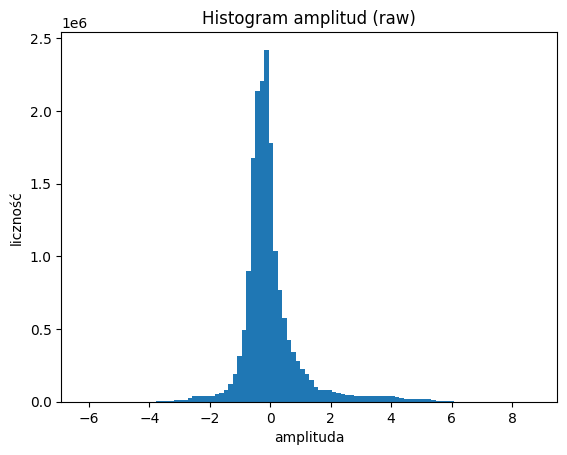

In [3]:
import matplotlib.pyplot as plt

def plot_histogram(X, title):
    plt.figure()
    plt.hist(X.flatten(), bins=100)
    plt.title(title)
    plt.xlabel("amplituda")
    plt.ylabel("liczność")
    plt.show()

plot_histogram(X_train_raw, "Histogram amplitud (raw)")

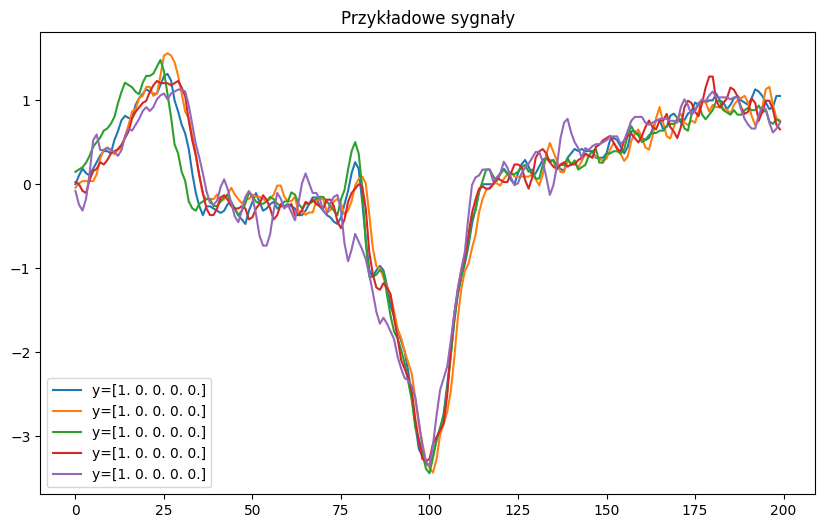

In [4]:
def plot_examples(X, y, n=5):
    plt.figure(figsize=(10, 6))
    for i in range(n):
        plt.plot(X[i], label=f"y={y[i]}")
    plt.legend()
    plt.title("Przykładowe sygnały")
    plt.show()

plot_examples(X_train_raw, y_train)

In [5]:
def detect_outliers(X, threshold=3.0):
    means = X.mean(axis=1)
    stds = X.std(axis=1)

    z_scores = np.abs((means - np.mean(means)) / np.std(means))
    outliers = np.where(z_scores > threshold)[0]

    print(f"Liczba outlierów: {len(outliers)}")
    return outliers

outliers = detect_outliers(X_train_raw)

Liczba outlierów: 1272


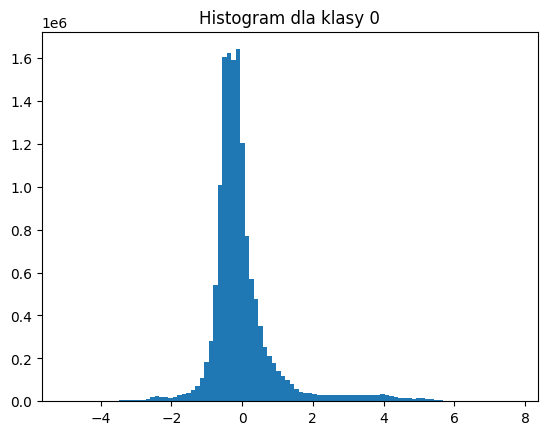

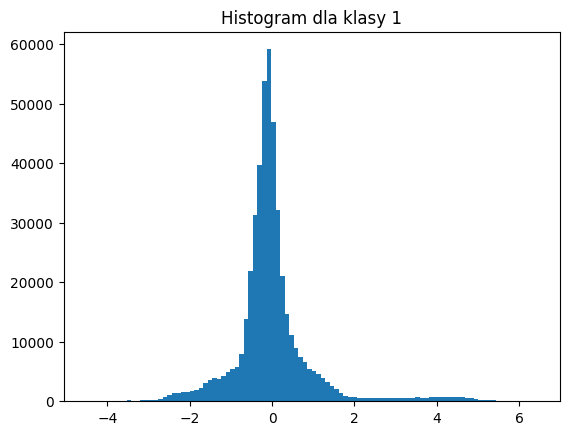

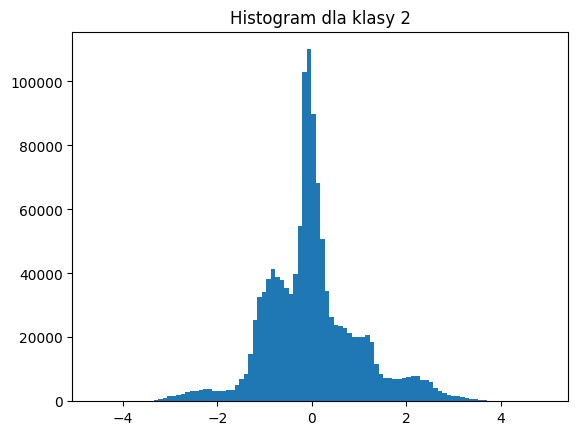

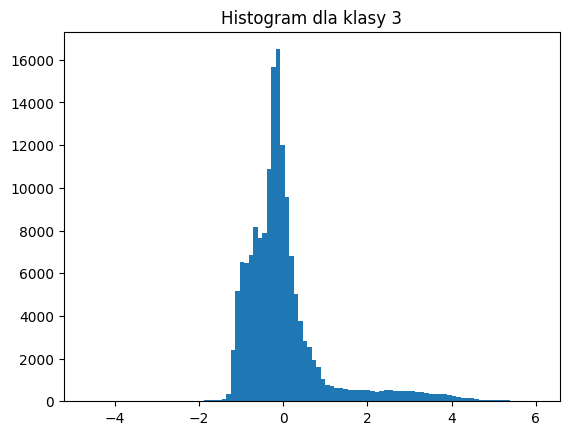

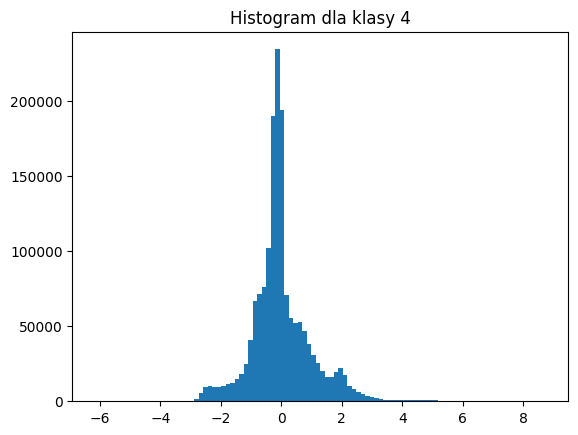

In [6]:
def plot_class_histograms(X, y):
    classes = np.unique(y)

    for cls in classes:
        plt.figure()
        subset = X[y == cls]
        plt.hist(subset.flatten(), bins=100)
        plt.title(f"Histogram dla klasy {cls}")
        plt.show()

plot_class_histograms(X_train_raw, y_train_raw)

# Porównaie metod rozwiązywania nierówności klas


### Ustawienia wspólne dla wszystkich eksperymentów

Dane są dzielone na zbiór treningowy, walidacyjny i testowy. Każdy model LSTM trenowany jest przez maksymalnie 15 epok z early stopping (cierpliwość 3 epoki). Docelowy rozkład klas przy augmentacji: 15 000 próbek na klasę.

In [7]:
from src.augmentation import augment
from src.build_functions import build_lstm

from keras.callbacks import EarlyStopping

In [8]:
X_train_lstm = X_train_raw[..., np.newaxis]
X_train_lstm, X_validation_lstm, y_train, y_validation = train_test_split(X_train_lstm, y_train,test_size=0.4, random_state=42)

X_test_lstm = X_test_raw[..., np.newaxis]

EPOCHES = 15
PATIENCE = 3

new_distribution = {
    0: 15000,
    1: 15000,
    2: 15000,
    3: 15000,
    4: 15000
}

### 3.1 Trening bez korekcji nierównowagi

Model trenowany na surowych, niezbalansowanych danych, jako punkt odniesienia dla pozostałych metod.

In [9]:
model = build_lstm()
history_standard = model.fit(
    X_train_lstm, y_train,
    validation_data=(X_validation_lstm, y_validation),
    epochs=EPOCHES,
    batch_size=256,
    callbacks=[
        EarlyStopping(
            monitor='val_loss', patience=PATIENCE, restore_best_weights=True
        )
    ]
)

E0000 00:00:1780247294.045729   18705 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.7836 - loss: 0.8567 - val_accuracy: 0.8145 - val_loss: 0.6524
Epoch 2/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.8097 - loss: 0.6617 - val_accuracy: 0.8040 - val_loss: 0.6287
Epoch 3/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - accuracy: 0.8202 - loss: 0.5925 - val_accuracy: 0.8460 - val_loss: 0.5111
Epoch 4/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.8588 - loss: 0.5134 - val_accuracy: 0.8621 - val_loss: 0.4915
Epoch 5/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 107ms/step - accuracy: 0.8661 - loss: 0.4852 - val_accuracy: 0.8595 - val_loss: 0.4804
Epoch 6/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - accuracy: 0.8673 - loss: 0.4737 - val_accuracy: 0.8708 - val_loss: 0.4326
Epoch 7/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.8735 - loss: 0.4455 - val_accuracy: 0.8840 - val_loss: 0.4112
Epoch 8/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - accuracy: 0.8812 - loss: 0.42

### 3.2 Ważenie klas

Rzadsze klasy otrzymują wyższe wagi w funkcji straty, co zmusza model do poświęcenia im większej uwagi bez fizycznego generowania nowych próbek.

In [10]:
total = sum(train_distributions)
n_classes = len(train_distributions)
class_weight = {
    cls: total / (n_classes * count)
    for cls, count in enumerate(train_distributions)
}
print(class_weight)

{0: 0.2499782873632454, 1: 7.529620253164557, 2: 2.7731468531468533, 3: 22.70381679389313, 4: 2.1635790494665375}


In [11]:
model1 = build_lstm()
history_weighted = model1.fit(
    X_train_lstm, y_train,
    validation_data=(X_validation_lstm, y_validation),
    epochs=EPOCHES,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(
            monitor='val_loss', patience=PATIENCE, restore_best_weights=True
        )
    ]
)

Epoch 1/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 24s 107ms/step - accuracy: 0.2996 - loss: 1.4045 - val_accuracy: 0.4503 - val_loss: 1.4114
Epoch 2/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step - accuracy: 0.4612 - loss: 1.1545 - val_accuracy: 0.5043 - val_loss: 1.2088
Epoch 3/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - accuracy: 0.4619 - loss: 1.0356 - val_accuracy: 0.4814 - val_loss: 1.1396
Epoch 4/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 23s 112ms/step - accuracy: 0.4732 - loss: 0.9583 - val_accuracy: 0.4702 - val_loss: 1.0761
Epoch 5/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 107ms/step - accuracy: 0.5169 - loss: 0.8804 - val_accuracy: 0.5026 - val_loss: 1.1189
Epoch 6/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.5988 - loss: 0.8247 - val_accuracy: 0.6567 - val_loss: 0.9453
Epoch 7/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 23s 108ms/step - accuracy: 0.6385 - loss: 0.8015 - val_accuracy: 0.7054 - val_loss: 0.9046
Epoch 8/15
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 107ms/step - accuracy: 0.6652 - loss: 0

### 3.3 Augmentacja: Time Warping

Mniej liczne klasy są dolosowywane przez losowe rozciąganie/ściskanie osi czasu sygnału (time warping). Teoretycznie pozwala to uzyskać nowe, realistyczne wariacje uderzeń serca.

In [12]:
X_train_tw, y_train_tw = augment(
    X_train_lstm,
    y_train,
    target_counts=new_distribution,
    mode="timewarp"
)

In [13]:
model2 = build_lstm()
history_tw = model2.fit(
    X_train_tw,
    y_train_tw,
    validation_data=(X_validation_lstm, y_validation),
    epochs=EPOCHES,
    batch_size=256,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True
        )
    ]
)

Epoch 1/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 30s 97ms/step - accuracy: 0.3716 - loss: 1.4274 - val_accuracy: 0.3339 - val_loss: 1.3722
Epoch 2/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 29s 99ms/step - accuracy: 0.4573 - loss: 1.3016 - val_accuracy: 0.3424 - val_loss: 1.3012
Epoch 3/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 28s 95ms/step - accuracy: 0.4816 - loss: 1.2493 - val_accuracy: 0.5045 - val_loss: 1.2259
Epoch 4/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 27s 94ms/step - accuracy: 0.4058 - loss: 1.4211 - val_accuracy: 0.2766 - val_loss: 1.4270
Epoch 5/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 27s 94ms/step - accuracy: 0.4431 - loss: 1.3597 - val_accuracy: 0.3623 - val_loss: 1.3731
Epoch 6/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 29s 99ms/step - accuracy: 0.4568 - loss: 1.3283 - val_accuracy: 0.1958 - val_loss: 1.4883


### 3.4 Augmentacja: Mixup

Mixup tworzy syntetyczne próbki jako interpolację liniową dwóch istniejących sygnałów i ich etykiet. Wygładza granice decyzyjne modelu.

In [14]:
X_train_mu, y_train_mu = augment(
    X_train_lstm,
    y_train,
    target_counts=new_distribution,
    mode="mixup"
)

In [15]:
model3 = build_lstm()
history_mu = model3.fit(
    X_train_mu,
    y_train_mu,
    validation_data=(X_validation_lstm, y_validation),
    epochs=EPOCHES,
    batch_size=256,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True
        )
    ]
)

Epoch 1/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 29s 96ms/step - accuracy: 0.4920 - loss: 1.2215 - val_accuracy: 0.4996 - val_loss: 1.1972
Epoch 2/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 27s 94ms/step - accuracy: 0.6649 - loss: 0.9117 - val_accuracy: 0.5622 - val_loss: 1.1184
Epoch 3/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - accuracy: 0.7037 - loss: 0.8197 - val_accuracy: 0.6249 - val_loss: 0.8882
Epoch 4/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - accuracy: 0.6928 - loss: 0.8302 - val_accuracy: 0.4733 - val_loss: 1.1433
Epoch 5/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 28s 95ms/step - accuracy: 0.7193 - loss: 0.7491 - val_accuracy: 0.7188 - val_loss: 0.7590
Epoch 6/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 28s 95ms/step - accuracy: 0.7671 - loss: 0.6386 - val_accuracy: 0.7962 - val_loss: 0.6188
Epoch 7/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 28s 95ms/step - accuracy: 0.7800 - loss: 0.6095 - val_accuracy: 0.7583 - val_loss: 0.6889
Epoch 8/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 27s 94ms/step - accuracy: 0.7830 - loss: 0.5988 - 

### 3.5 Augmentacja: Time Warping + Mixup

Połączenie obu technik augmentacji, najpierw time warping, potem mixup

In [16]:
X_train_au, y_train_au = augment(
    X_train_lstm,
    y_train,
    target_counts=new_distribution,
    mode="timewarp_mixup"
)

In [17]:
model4 = build_lstm()
history_au = model4.fit(
    X_train_au,
    y_train_au,
    validation_data=(X_validation_lstm, y_validation),
    epochs=EPOCHES,
    batch_size=256,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True
        )
    ]
)

Epoch 1/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 29s 94ms/step - accuracy: 0.3614 - loss: 1.4434 - val_accuracy: 0.2944 - val_loss: 1.2903
Epoch 2/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - accuracy: 0.3830 - loss: 1.4211 - val_accuracy: 0.2355 - val_loss: 1.4755
Epoch 3/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 28s 95ms/step - accuracy: 0.4607 - loss: 1.3055 - val_accuracy: 0.5972 - val_loss: 1.2200
Epoch 4/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 28s 95ms/step - accuracy: 0.5241 - loss: 1.1856 - val_accuracy: 0.7842 - val_loss: 0.9767
Epoch 5/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - accuracy: 0.5634 - loss: 1.1134 - val_accuracy: 0.7519 - val_loss: 0.9411
Epoch 6/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - accuracy: 0.6190 - loss: 1.0111 - val_accuracy: 0.8219 - val_loss: 0.6165
Epoch 7/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - accuracy: 0.6485 - loss: 0.9370 - val_accuracy: 0.8010 - val_loss: 0.6690
Epoch 8/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - accuracy: 0.6646 - loss: 0.8966 - 

### Porównanie wyników metod radzenia sobie z niezbalansowanym zbiorem danych

In [ ]:
from src.evaluation import evaluate_model, compare_training

models = {
    "model_on_standard_data": model,
    "model_with_weights": model1,
    "model_on_timeworp_data": model2,
    "model_on_mixup_data": model3,
    "model_on_timeworp+mixup_data": model4
}

results = {}
cms = {}

for name, m in models.items():
    acc, cm = evaluate_model(m, X_test_lstm, y_test, name=name)
    results[name] = acc
    cms[name] = cm


===== model_on_standard_data =====
Accuracy: 0.7950
              precision    recall  f1-score   support

           0       0.92      0.85      0.89     19216
           1       0.42      0.01      0.02       411
           2       0.27      0.58      0.37       800
           3       0.00      0.00      0.00        16
           4       0.45      0.59      0.51      2903

    accuracy                           0.80     23346
   macro avg       0.41      0.41      0.36     23346
weighted avg       0.83      0.80      0.80     23346


===== model_with_weights =====
Accuracy: 0.6297
              precision    recall  f1-score   support

           0       0.92      0.64      0.75     19216
           1       0.07      0.10      0.08       411
           2       0.44      0.65      0.52       800
           3       0.00      0.06      0.00        16
           4       0.31      0.66      0.42      2903

    accuracy                           0.63     23346
   macro avg       0.35      

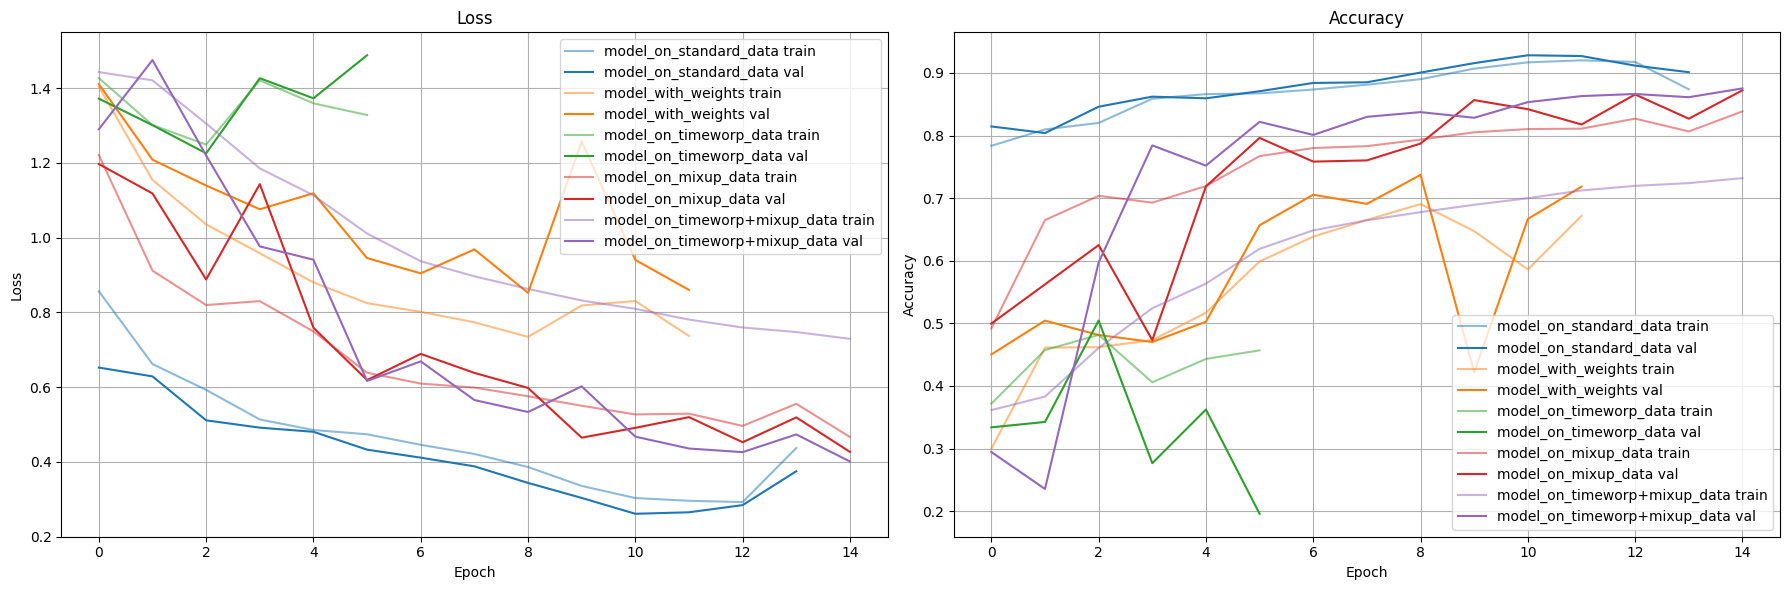

In [31]:
lables = [ "model_on_standard_data", "model_with_weights", "model_on_timeworp_data", "model_on_mixup_data", "model_on_timeworp+mixup_data"]
histories = [history_standard, history_weighted, history_tw, history_mu, history_au]
compare_training(histories, lables)

### mieszanie danych bez timewrap daje najlepszą reprezętację klas mniejszościowych przy zachownaiu wysokiej dokładności

Accuracy: 0.6300

===== model_on_mixup_data =====

              precision    recall  f1-score   support

           0       0.95      0.62      0.75     19216
           1       0.05      0.09      0.06       411
           2       0.23      0.72      0.35       800
           3       0.00      0.06      0.00        16
           4       0.57      0.78      0.66      2903

## 4. Dodatkowy preprocessing sygnału

Sprawdzamy, czy filtrowanie sygnału (filtr pasmowy) i transformacja do dziedziny częstotliwości (FFT) poprawią wyniki najlepszego modelu (mixup). Trenowane są dwa dodatkowe modele LSTM na tych reprezentacjach.

In [34]:
from src.augmentation import bandpass, compute_fft

X_train_band = np.array([
    bandpass(x.squeeze())
    for x in X_train_mu
])[..., np.newaxis]
X_validation_band = np.array([
    bandpass(x.squeeze())
    for x in X_validation_lstm
])[..., np.newaxis]

X_test_band = np.array([
    bandpass(x.squeeze())
    for x in X_test_raw
])[..., np.newaxis]


model_bandpass = build_lstm()
history_bandpass = model4.fit(
    X_train_band,
    y_train_au,
    validation_data=(X_validation_band, y_validation),
    epochs=EPOCHES,
    batch_size=256,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True
        )
    ]
)

Epoch 1/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 36s 123ms/step - accuracy: 0.1994 - loss: 1.6621 - val_accuracy: 0.4661 - val_loss: 1.5703
Epoch 2/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 28s 97ms/step - accuracy: 0.2004 - loss: 1.6161 - val_accuracy: 0.4095 - val_loss: 1.5909
Epoch 3/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 28s 96ms/step - accuracy: 0.1996 - loss: 1.6127 - val_accuracy: 0.1512 - val_loss: 1.6210
Epoch 4/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 28s 96ms/step - accuracy: 0.2027 - loss: 1.6114 - val_accuracy: 0.7212 - val_loss: 1.5805


In [35]:
X_train_fft = np.array([
    compute_fft(x.squeeze())
    for x in X_train_band
])[..., np.newaxis]
X_validation_fft = np.array([
    compute_fft(x.squeeze())
    for x in X_validation_lstm
])[..., np.newaxis]

X_test_fft = np.array([
    compute_fft(x.squeeze())
    for x in X_test_raw
])[..., np.newaxis]

model_fft = build_lstm()
history_fft = model4.fit(
    X_train_fft,
    y_train_au,
    validation_data=(X_validation_fft, y_validation),
    epochs=EPOCHES,
    batch_size=256,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True
        )
    ]
)

Epoch 1/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - accuracy: 0.2019 - loss: 1.6127 - val_accuracy: 0.7021 - val_loss: 1.5652
Epoch 2/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.1999 - loss: 1.6109 - val_accuracy: 0.3059 - val_loss: 1.6095
Epoch 3/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy: 0.1998 - loss: 1.6104 - val_accuracy: 0.2854 - val_loss: 1.6131
Epoch 4/15
293/293 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.2025 - loss: 1.6102 - val_accuracy: 0.6072 - val_loss: 1.5831


In [39]:
models = {
    "model_on_mixup_data": model3,
    "model_on_bandpass_data": model_bandpass,
    "model_on_fft_data": model_fft
}
data = [X_test_lstm, X_test_band, X_test_fft]

results = {}
cms = {}

for idx, (name, model) in enumerate(models.items()):
    acc, cm = evaluate_model(
        model,
        data[idx],
        y_test,
        name=name
    )
    results[name] = acc
    cms[name] = cm


===== model_on_mixup_data =====
Accuracy: 0.6300
              precision    recall  f1-score   support

           0       0.95      0.62      0.75     19216
           1       0.05      0.09      0.06       411
           2       0.23      0.72      0.35       800
           3       0.00      0.06      0.00        16
           4       0.57      0.78      0.66      2903

    accuracy                           0.63     23346
   macro avg       0.36      0.45      0.36     23346
weighted avg       0.86      0.63      0.71     23346


===== model_on_bandpass_data =====
Accuracy: 0.5288
              precision    recall  f1-score   support

           0       0.86      0.63      0.73     19216
           1       0.02      0.34      0.03       411
           2       0.00      0.00      0.00       800
           3       0.00      0.00      0.00        16
           4       0.33      0.00      0.00      2903

    accuracy                           0.53     23346
   macro avg       0.24     

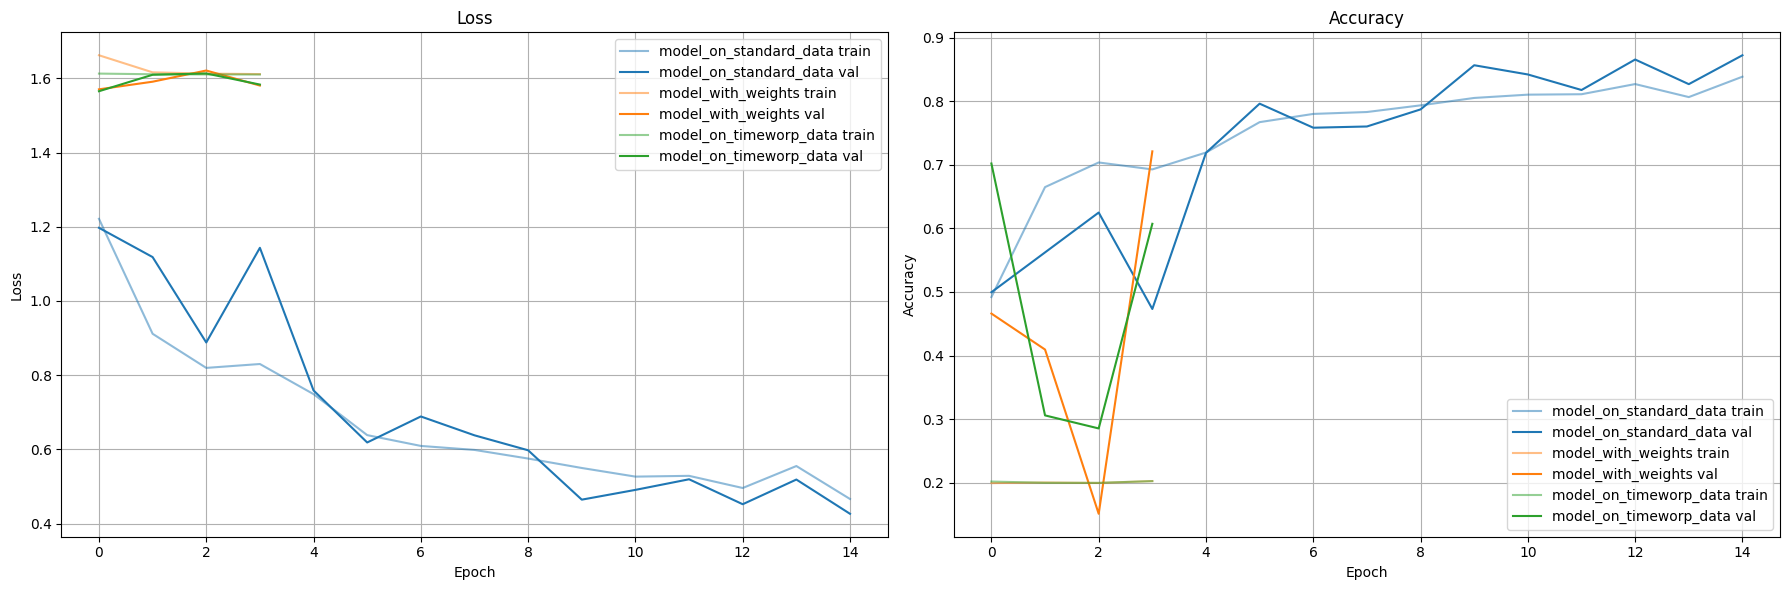

In [40]:
models = [ "model_on_mixup_data", "model_on_bandpass_data", "model_on_fft_data"]
histories = [ history_mu, history_bandpass, history_fft]
compare_training(histories, lables)

Dalszy preprocesing danych nie pomógł w uzyskaniu lepszych wyników 

## 5. Strojenie hiperparametrów (Bayesian Optimization)

Używamy biblioteki Keras Tuner z algorytmem bayesowskim do automatycznego doboru architektury modelu LSTM Przeszukiwanych jest 50 konfiguracji po 30 epok.

In [ ]:
import keras_tuner as kt
from src.build_functions import build_lstm_from_hp

tuner = kt.BayesianOptimization(
    build_lstm_from_hp,
    objective='val_accuracy',
    max_trials=50,
    directory='bayesian_tuning',
    project_name='arytmia_lstm'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

tuner.search(
    X_train_mu,
    y_train_mu,
    validation_data=(X_validation_lstm, y_validation),
    epochs=12,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)



Reloading Tuner from bayesian_tuning/arytmia_lstm/tuner0.json


In [43]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
model = tuner.hypermodel.build(best_hp)
# model = tuner.get_best_models()[0]

/home/krzysztof/Documents/ArytmiaLSTM/.ArytmiaEnv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
history = model.fit(
    X_train_mu,
    y_train_mu,
    validation_data=(X_validation_lstm, y_validation),
    epochs=10,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)
model.save("best_lstm_model.keras")

Epoch 1/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 329s 1s/step - accuracy: 0.6133 - loss: 1.1076 - val_accuracy: 0.7929 - val_loss: 0.7930
Epoch 2/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 335s 1s/step - accuracy: 0.7888 - loss: 0.6446 - val_accuracy: 0.8389 - val_loss: 0.5090
Epoch 3/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 352s 1s/step - accuracy: 0.8426 - loss: 0.4919 - val_accuracy: 0.8353 - val_loss: 0.4993
Epoch 4/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - accuracy: 0.8689 - loss: 0.4147 - val_accuracy: 0.8855 - val_loss: 0.3851
Epoch 5/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - accuracy: 0.8912 - loss: 0.3503 - val_accuracy: 0.8802 - val_loss: 0.3870
Epoch 6/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.9071 - loss: 0.3063 - val_accuracy: 0.8887 - val_loss: 0.3491
Epoch 7/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.9156 - loss: 0.2795 - val_accuracy: 0.9139 - val_loss: 0.2911
Epoch 8/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.9242 - loss: 0.2535 - val_accu

## 6. Ewaluacja i wizualizacja najlepszego modelu

Najlepszy model (po strojeniu) jest ładowany i oceniany na zbiorze testowym. Prezentujemy: macierz pomyłek (surową i znormalizowaną) oraz krzywe ROC z wartościami AUC dla każdej klasy.

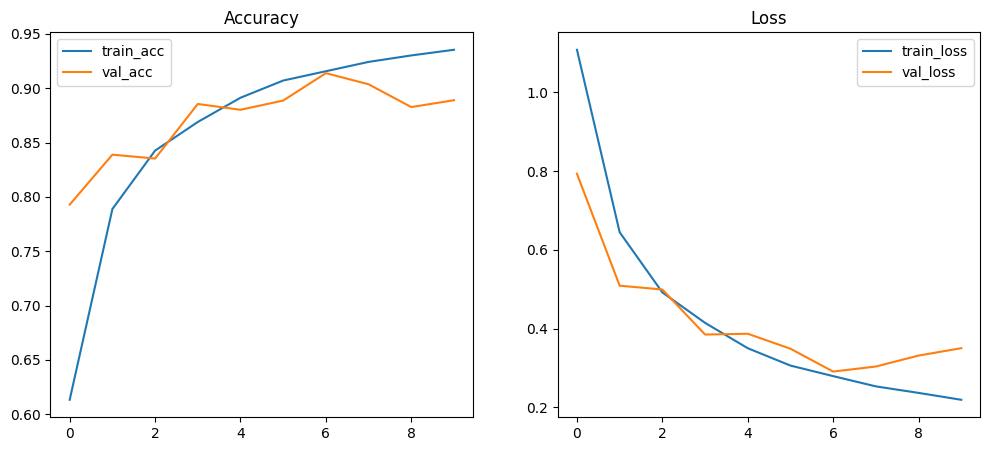

In [48]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()

plt.show()

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("best_lstm_model.keras")
evaluate_model(model, X_test_lstm, y_test, "tuned_model");


===== model =====
Accuracy: 0.5989
              precision    recall  f1-score   support

           0       0.95      0.57      0.71     19216
           1       0.02      0.13      0.04       411
           2       0.21      0.78      0.33       800
           3       0.00      0.06      0.00        16
           4       0.61      0.80      0.69      2903

    accuracy                           0.60     23346
   macro avg       0.36      0.47      0.35     23346
weighted avg       0.86      0.60      0.69     23346



730/730 ━━━━━━━━━━━━━━━━━━━━ 49s 67ms/step


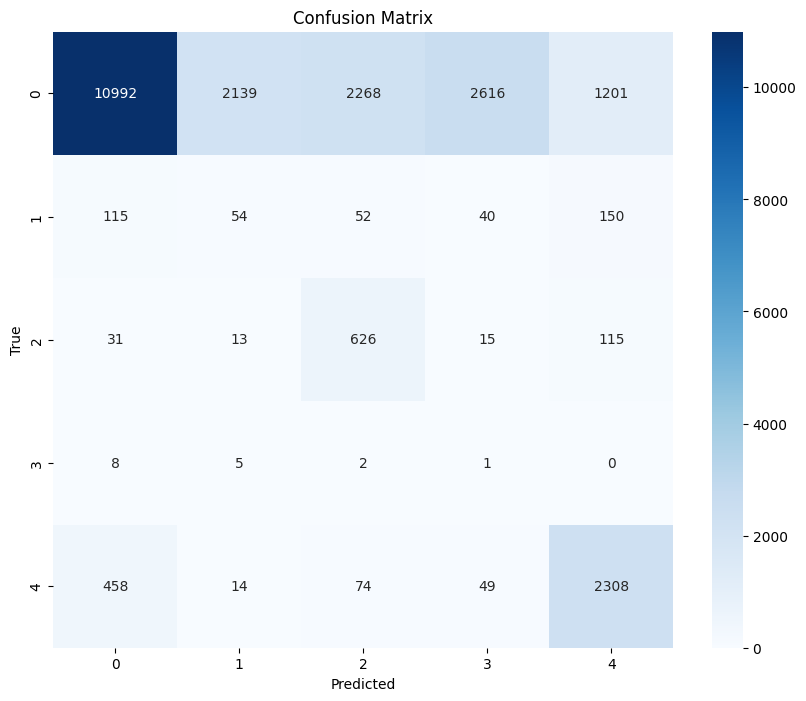

In [51]:
import seaborn as sns

y_pred_prob = model.predict(X_test_lstm)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

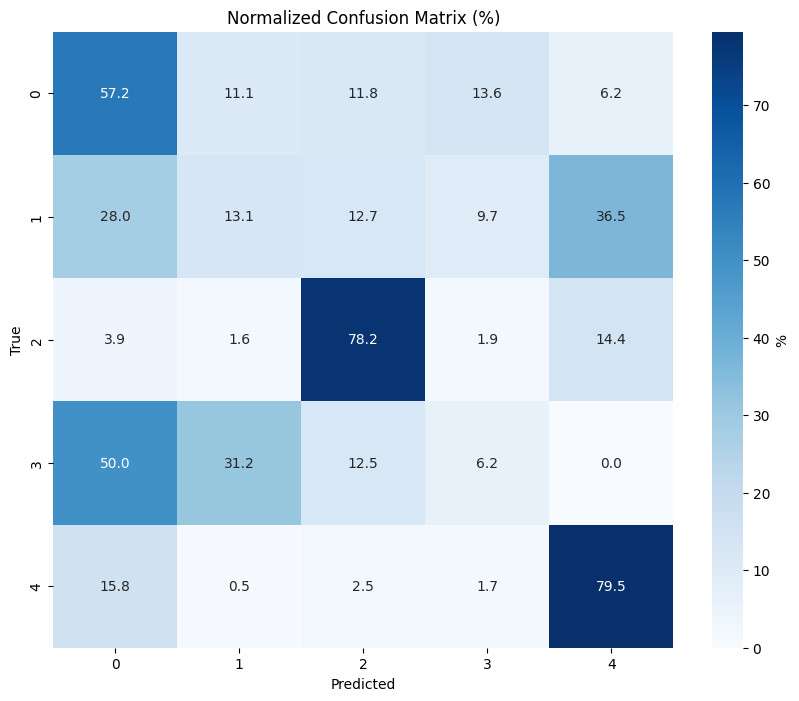

In [ ]:

cmn_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(
    cmn_normalized,
    annot=True,
    fmt='.1f', 
    cmap='Blues',
    cbar_kws={'label': '%'}
)
plt.title('Normalized Confusion Matrix (%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

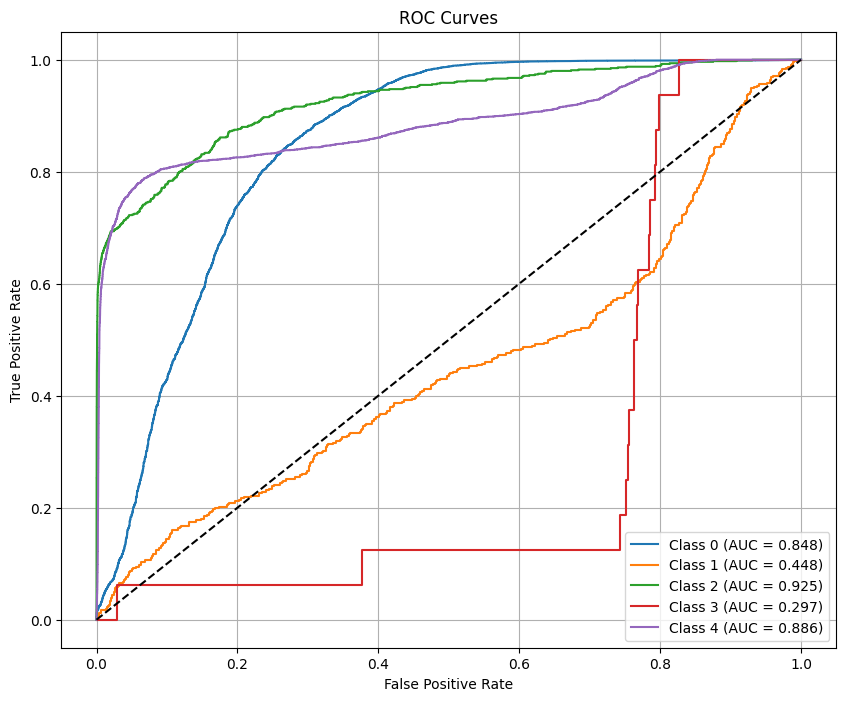

In [54]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

n_classes = y_test.shape[1]
y_true_bin = y_test

plt.figure(figsize=(10, 8))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i} (AUC = {roc_auc:.3f})'
    )

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid()
plt.show()
